# GROUP 6 — Pima Indians Diabetes: Complete Machine Learning Solution

**Goal:** Build a leakage-safe binary classification system that predicts whether a patient has diabetes (`Outcome = 1`) or not (`Outcome = 0`).

This notebook follows the required workflow:
1. Problem Definition
2. Data Collection / Generation
3. Data Inspection
4. Data Quality Assessment
5. Exploratory Data Analysis
6. Data Cleaning
7. Feature Engineering
8. Feature Selection
9. Train/Validation/Test Split
10. Data Preprocessing
11. Baseline Model
12. Model Training
13. Model Comparison
14. Hyperparameter Tuning
15. Cross-Validation
16. Final Evaluation
17. Error Analysis
18. Model Interpretation
19. Model Saving
20. Deployment

It also answers the 23 investigation questions from the assignment.


## 1. Problem Definition

The problem is **early diabetes classification** from clinical measurements.

- **Machine Learning type:** supervised learning → binary classification.
- **Target:** `Outcome`.
- `0` = not diabetic / negative test.
- `1` = diabetic / positive test.
- The model should be evaluated with **Recall, Precision, F1, Accuracy and ROC-AUC**. Because missing a diabetic patient can be more serious than generating a false alarm, Recall should receive particular attention.

The dataset is the well-known Pima Indians Diabetes dataset: 768 observations, 8 predictors and a binary target. The standard dataset contains 500 class-0 and 268 class-1 observations. Several zero values in clinical measurements are physiologically implausible and are commonly treated as missing values rather than true measurements.


## 2. Imports and Reproducibility

In [51]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_validate, GridSearchCV
)
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay, RocCurveDisplay
)

warnings.filterwarnings("ignore")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Libraries imported successfully.")


Libraries imported successfully.


## 3. Data Collection / Generation



Our dataset downloaded from kaggle: https://www.kaggle.com/datasets/vishvaachhatrara/missing-values-pima-indians-diabetes-data

## 4. Load the Raw Dataset and Preserve It

In [52]:
raw_df_original= pd.read_csv("pima_Missing_values.csv")
raw_df = raw_df_original.copy(deep=True)

print("Raw shape:", raw_df.shape)
display(raw_df.head())
print("\nOriginal columns:")
print(raw_df.columns.tolist())

Raw shape: (690, 9)


,NoOfPregency,PlasmaGlucoseCon,BloodPressure,SkinFoldThickness,Insuline,BMI,DiabetesPedigree,Age,Class
0,10,108,66,<null>,0,32.4,0.272,42,tested_positive
1,7,107,74,0,0,29.6,0.254,31,tested_positive
2,0,179,90,27,<null>,<null>,0.686,23,tested_positive
3,10,125,70,26,<null>,31.1,0.205,41,tested_positive
4,10,<null>,<null>,0,0,38,0.537,34,tested_positive



Original columns:
['NoOfPregency', 'PlasmaGlucoseCon', 'BloodPressure', 'SkinFoldThickness', 'Insuline', 'BMI', 'DiabetesPedigree', 'Age', 'Class']


In [53]:
print(raw_df.columns)

Index(['NoOfPregency', 'PlasmaGlucoseCon', 'BloodPressure',
       'SkinFoldThickness', 'Insuline', 'BMI', 'DiabetesPedigree', 'Age',
       'Class'],
      dtype='str')


## 5. Standardize Column Names

The original Pima dataset is commonly distributed either with headers or without headers. The following cell handles both situations.


In [54]:
EXPECTED_COLUMNS = [
    "Pregnancies", "Glucose", "BloodPressure", "SkinThickness",
    "Insulin", "BMI", "DiabetesPedigreeFunction", "Age", "Outcome"
]

if raw_df.shape[1] == 9:
    normalized = [str(c).strip().lower().replace("_", "").replace(" ", "") for c in raw_df.columns]
    expected_norm = [c.lower().replace("_", "").replace(" ", "") for c in EXPECTED_COLUMNS]

    if normalized != expected_norm:
        raw_df.columns = EXPECTED_COLUMNS

# Normalize common alternative spellings.
rename_map = {}
for c in raw_df.columns:
    key = str(c).strip().lower().replace("_", "").replace(" ", "")
    aliases = {
        "preg": "Pregnancies",
        "pregnant": "Pregnancies",
        "pregnancies": "Pregnancies",
        "plas": "Glucose",
        "gluc": "Glucose",
        "glucose": "Glucose",
        "pres": "BloodPressure",
        "bp": "BloodPressure",
        "bloodpressure": "BloodPressure",
        "skin": "SkinThickness",
        "triceps": "SkinThickness",
        "skinthickness": "SkinThickness",
        "insu": "Insulin",
        "insulin": "Insulin",
        "mass": "BMI",
        "bmi": "BMI",
        "pedi": "DiabetesPedigreeFunction",
        "pedigree": "DiabetesPedigreeFunction",
        "diabetespedigreefunction": "DiabetesPedigreeFunction",
        "age": "Age",
        "class": "Outcome",
        "outcome": "Outcome",
        "diabetes": "Outcome"
    }
    if key in aliases:
        rename_map[c] = aliases[key]

raw_df = raw_df.rename(columns=rename_map)

missing_expected = [c for c in EXPECTED_COLUMNS if c not in raw_df.columns]
if missing_expected:
    raise ValueError(f"Missing expected columns: {missing_expected}. Found: {list(raw_df.columns)}")

raw_df = raw_df[EXPECTED_COLUMNS].copy()

# Force numeric values where possible.
for col in EXPECTED_COLUMNS:
    raw_df[col] = pd.to_numeric(raw_df[col], errors="coerce")

print(raw_df.dtypes)
display(raw_df.head())
# ===== FIX: Map the string target labels to 0 / 1 =====
print("Unique values in Outcome before mapping:")
print(raw_df["Outcome"].unique())

# Map string labels to binary
raw_df["Outcome"] = raw_df["Outcome"].replace({
    "tested_negative": 0,
    "tested_positive": 1,
    "0": 0,
    "1": 1
})

# Convert to integer
raw_df["Outcome"] = pd.to_numeric(raw_df["Outcome"], errors="coerce")

print("\nUnique values after mapping:")
print(raw_df["Outcome"].value_counts(dropna=False))


Pregnancies                 float64
Glucose                     float64
BloodPressure               float64
SkinThickness               float64
Insulin                     float64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                         float64
Outcome                     float64
dtype: object


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,10.0,108.0,66.0,NaN,0.0,32.4,0.272,42.0,NaN
1,7.0,107.0,74.0,0.0,0.0,29.6,0.254,31.0,NaN
2,0.0,179.0,90.0,27.0,NaN,NaN,0.686,23.0,NaN
3,10.0,125.0,70.0,26.0,NaN,31.1,0.205,41.0,NaN
4,10.0,NaN,NaN,0.0,0.0,38.0,0.537,34.0,NaN


Unique values in Outcome before mapping:
[nan]

Unique values after mapping:
Outcome
NaN    690
Name: count, dtype: int64


## 6. Data Inspection

Required checks: dimensions, columns, data types, descriptive statistics and missing values.


In [55]:
print("Dimensions:", raw_df.shape)
print("\nColumns:")
print(raw_df.columns.tolist())

print("\nData types:")
print(raw_df.dtypes)

print("\nDescriptive statistics:")
display(raw_df.describe().T)

print("\nExplicit missing values:")
missing_count = raw_df.isna().sum()
missing_pct = raw_df.isna().mean().mul(100).round(2)
missing_table = pd.DataFrame({
    "Missing_Count": missing_count,
    "Missing_Percentage": missing_pct
})
display(missing_table)


Dimensions: (690, 9)

Columns:
['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

Data types:
Pregnancies                 float64
Glucose                     float64
BloodPressure               float64
SkinThickness               float64
Insulin                     float64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                         float64
Outcome                     float64
dtype: object

Descriptive statistics:


,count,mean,std,min,25%,50%,75%,max
Pregnancies,624.0,3.782051,3.353530,0.000,1.000,3.000,6.0000,17.00
Glucose,621.0,120.586151,31.691167,0.000,99.000,116.000,139.0000,199.00
BloodPressure,612.0,68.841503,19.604336,0.000,64.000,72.000,80.0000,114.00
SkinThickness,625.0,20.339200,15.943816,0.000,0.000,23.000,32.0000,99.00
Insulin,618.0,83.707120,119.446115,0.000,0.000,39.000,130.0000,846.00
BMI,624.0,31.887981,7.963690,0.000,26.975,32.000,36.4250,67.10
DiabetesPedigreeFunction,615.0,0.468171,0.331741,0.078,0.245,0.371,0.6145,2.42
Age,629.0,32.844197,11.610637,21.000,24.000,29.000,40.0000,72.00
Outcome,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN



Explicit missing values:


,Missing_Count,Missing_Percentage
Pregnancies,66,9.57
Glucose,69,10.00
BloodPressure,78,11.30
SkinThickness,65,9.42
Insulin,72,10.43
BMI,66,9.57
DiabetesPedigreeFunction,75,10.87
Age,61,8.84
Outcome,690,100.00


## 7. Data Quality Assessment — Are Zeros Really Missing?

`Pregnancies = 0` is valid: a patient can have no previous pregnancies.

`Outcome = 0` is also valid: it is the negative class.

For the standard Pima data, zero values in `Glucose`, `BloodPressure`, `SkinThickness`, `Insulin` and `BMI` are treated as missing because zero is physiologically implausible for these measurements. This is the key data-quality issue in this dataset.


In [56]:
zero_sensitive_cols = [
    "Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"
]

zero_table = pd.DataFrame({
    "Zero_Count": [int((raw_df[c] == 0).sum()) for c in EXPECTED_COLUMNS],
    "Zero_Percentage": [round((raw_df[c] == 0).mean() * 100, 2) for c in EXPECTED_COLUMNS]
}, index=EXPECTED_COLUMNS)

display(zero_table)

# Create a cleaned working copy. Never modify the preserved raw copy.
df = raw_df.copy(deep=True)

for col in zero_sensitive_cols:
    df[col] = df[col].replace(0, np.nan)

print("Missing values after converting physiologically impossible zeros to NaN:")
display(pd.DataFrame({
    "Missing_Count": df.isna().sum(),
    "Missing_Percentage": df.isna().mean().mul(100).round(2)
}))


,Zero_Count,Zero_Percentage
Pregnancies,95,13.77
Glucose,4,0.58
BloodPressure,30,4.35
SkinThickness,186,26.96
Insulin,297,43.04
BMI,9,1.30
DiabetesPedigreeFunction,0,0.00
Age,0,0.00
Outcome,0,0.00


Missing values after converting physiologically impossible zeros to NaN:


,Missing_Count,Missing_Percentage
Pregnancies,66,9.57
Glucose,73,10.58
BloodPressure,108,15.65
SkinThickness,251,36.38
Insulin,369,53.48
BMI,75,10.87
DiabetesPedigreeFunction,75,10.87
Age,61,8.84
Outcome,690,100.00


## 7.1 Handling missing values

In [57]:
# Columns to fill with median
fill_cols = ['SkinThickness', 'Insulin']

# Columns where we will drop rows that have missing values
drop_cols = ['Glucose', 'BloodPressure', 'BMI', 'DiabetesPedigreeFunction', 'Age' ,'Pregnancies']

# 1. Fill median for SkinThickness and Insulin
for col in fill_cols:
    median_val = raw_df[col].median()
    raw_df[col] = raw_df[col].fillna(median_val)
    print(f"Filled {col} with median = {median_val:.2f}")

# 2. Drop rows that still have missing values in the remaining columns
raw_df = raw_df.dropna(subset=drop_cols)

# Optional: check remaining missing values
print("\nMissing values after cleaning:")
print(raw_df.isnull().sum())

Filled SkinThickness with median = 23.00
Filled Insulin with median = 39.00

Missing values after cleaning:
Pregnancies                   0
Glucose                       0
BloodPressure                 0
SkinThickness                 0
Insulin                       0
BMI                           0
DiabetesPedigreeFunction      0
Age                           0
Outcome                     376
dtype: int64


## 8. Duplicates and Outliers

Duplicate rows: 0


,Feature,Q1,Q3,IQR,Lower_Bound,Upper_Bound,Outlier_Count
0,Pregnancies,1.00000,6.00000,5.000,-6.50000,13.50000,1
1,Glucose,99.00000,137.00000,38.000,42.00000,194.00000,10
2,BloodPressure,63.50000,80.00000,16.500,38.75000,104.75000,25
3,SkinThickness,0.00000,31.00000,31.000,-46.50000,77.50000,0
4,Insulin,0.00000,116.75000,116.750,-175.12500,291.87500,15
5,BMI,26.75000,36.52500,9.775,12.08750,51.18750,12
6,DiabetesPedigreeFunction,0.24875,0.58875,0.340,-0.26125,1.09875,21
7,Age,23.00000,40.00000,17.000,-2.50000,65.50000,5


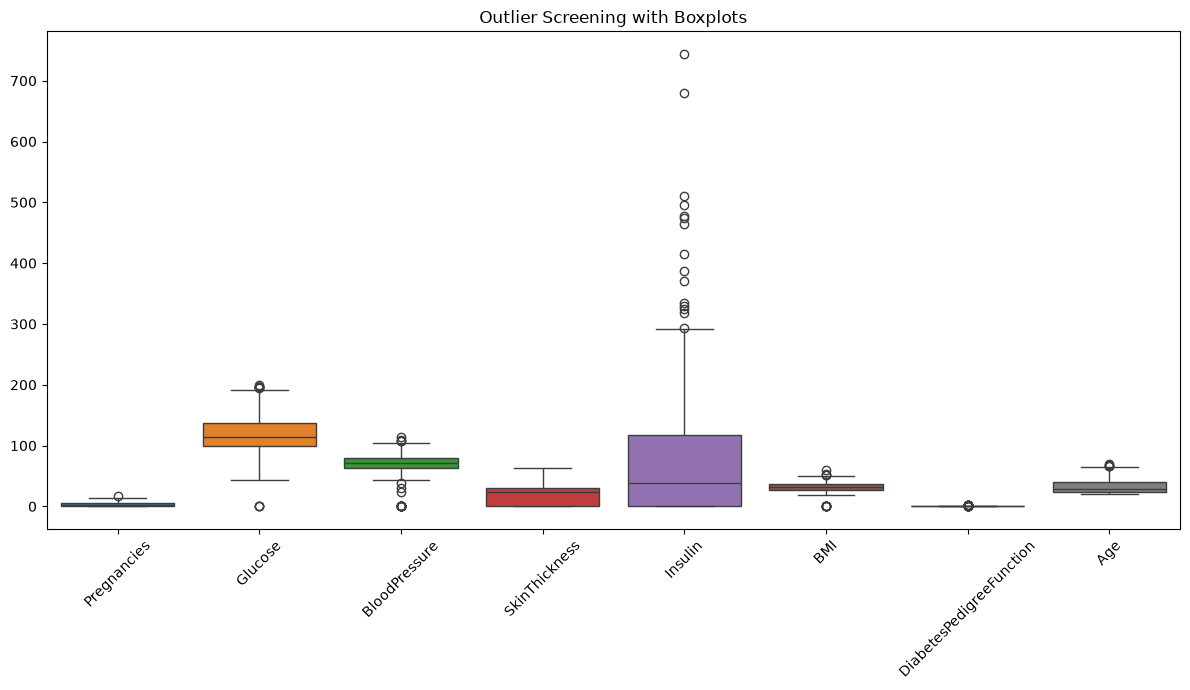

In [58]:
duplicate_count = int(raw_df.duplicated().sum())
print("Duplicate rows:", duplicate_count)

# Display duplicate rows if any.
if duplicate_count:
    display(raw_df[raw_df.duplicated(keep=False)].sort_values(EXPECTED_COLUMNS))

# IQR-based outlier screening.
feature_cols = EXPECTED_COLUMNS[:-1]
outlier_summary = []

for col in feature_cols:
    s = raw_df[col].dropna()
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    count = int(((s < lower) | (s > upper)).sum())
    outlier_summary.append([col, q1, q3, iqr, lower, upper, count])

outlier_table = pd.DataFrame(
    outlier_summary,
    columns=["Feature", "Q1", "Q3", "IQR", "Lower_Bound", "Upper_Bound", "Outlier_Count"]
)
display(outlier_table)

plt.figure(figsize=(12, 7))
sns.boxplot(data=raw_df[feature_cols])
plt.xticks(rotation=45)
plt.title("Outlier Screening with Boxplots")
plt.tight_layout()
plt.show()


### Outlier decision

| Feature                    | Outlier Count | Decision                  | Action                          | Reason |
|---------------------------|---------------|---------------------------|----------------------------------|--------|
| Pregnancies               | 1             | Keep                      | No action                        | Extremely rare |
| Glucose                   | 10            | Keep                      | No action                        | Clinically important |
| BloodPressure             | 25            | Keep                      | No action                        | Real hypertensive values exist |
| SkinThickness             | 0             | Keep                      | No action                        | No outliers detected |
| **Insulin**               | 15            | **Keep + Mild Cap**       | Winsorize (1%–99%)               | Highly skewed & extreme values |
| BMI                       | 12            | Keep                      | No action                        | Real obesity values exist |
| DiabetesPedigreeFunction  | 21            | Keep                      | No action                        | Genetic risk can be extreme |
| Age                       | 5             | Keep                      | No action                        | Very few outliers |


In [59]:
# ===== RESTORE Outcome FROM ORIGINAL DATA =====

# 1. Restore the original target column
raw_df["Outcome"] = raw_df_original["Class"].copy()

print("Restored original Class values:")
print(raw_df["Outcome"].value_counts(dropna=False))

# 2. Map the string labels to 0 and 1
raw_df["Outcome"] = raw_df["Outcome"].replace({
    "tested_negative": 0,
    "tested_positive": 1
})

# 3. Convert to integer
raw_df["Outcome"] = raw_df["Outcome"].astype(int)

print("\nAfter proper mapping:")
print(raw_df["Outcome"].value_counts(dropna=False))

Restored original Class values:
Outcome
tested_negative    253
tested_positive    123
Name: count, dtype: int64

After proper mapping:
Outcome
0    253
1    123
Name: count, dtype: int64


## 9. Class Imbalance

         Count  Percentage
Outcome                   
0          253       67.29
1          123       32.71


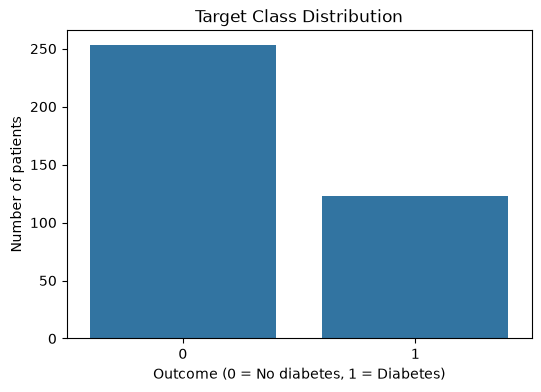

In [60]:
df = raw_df.copy()

class_counts = df["Outcome"].value_counts().sort_index()
class_pct = df["Outcome"].value_counts(normalize=True).sort_index().mul(100).round(2)

class_table = pd.DataFrame({
    "Count": class_counts,
    "Percentage": class_pct
})

print(class_table)

plt.figure(figsize=(6, 4))
sns.countplot(x="Outcome", data=df)
plt.title("Target Class Distribution")
plt.xlabel("Outcome (0 = No diabetes, 1 = Diabetes)")
plt.ylabel("Number of patients")
plt.show()

### Interpretation

The standard dataset contains 253 class-0 observations and 123 class-1 observations, approximately 67.29% vs 32.71%. Therefore the target is **moderately imbalanced**, not extremely imbalanced.

## 10. Exploratory Data Analysis

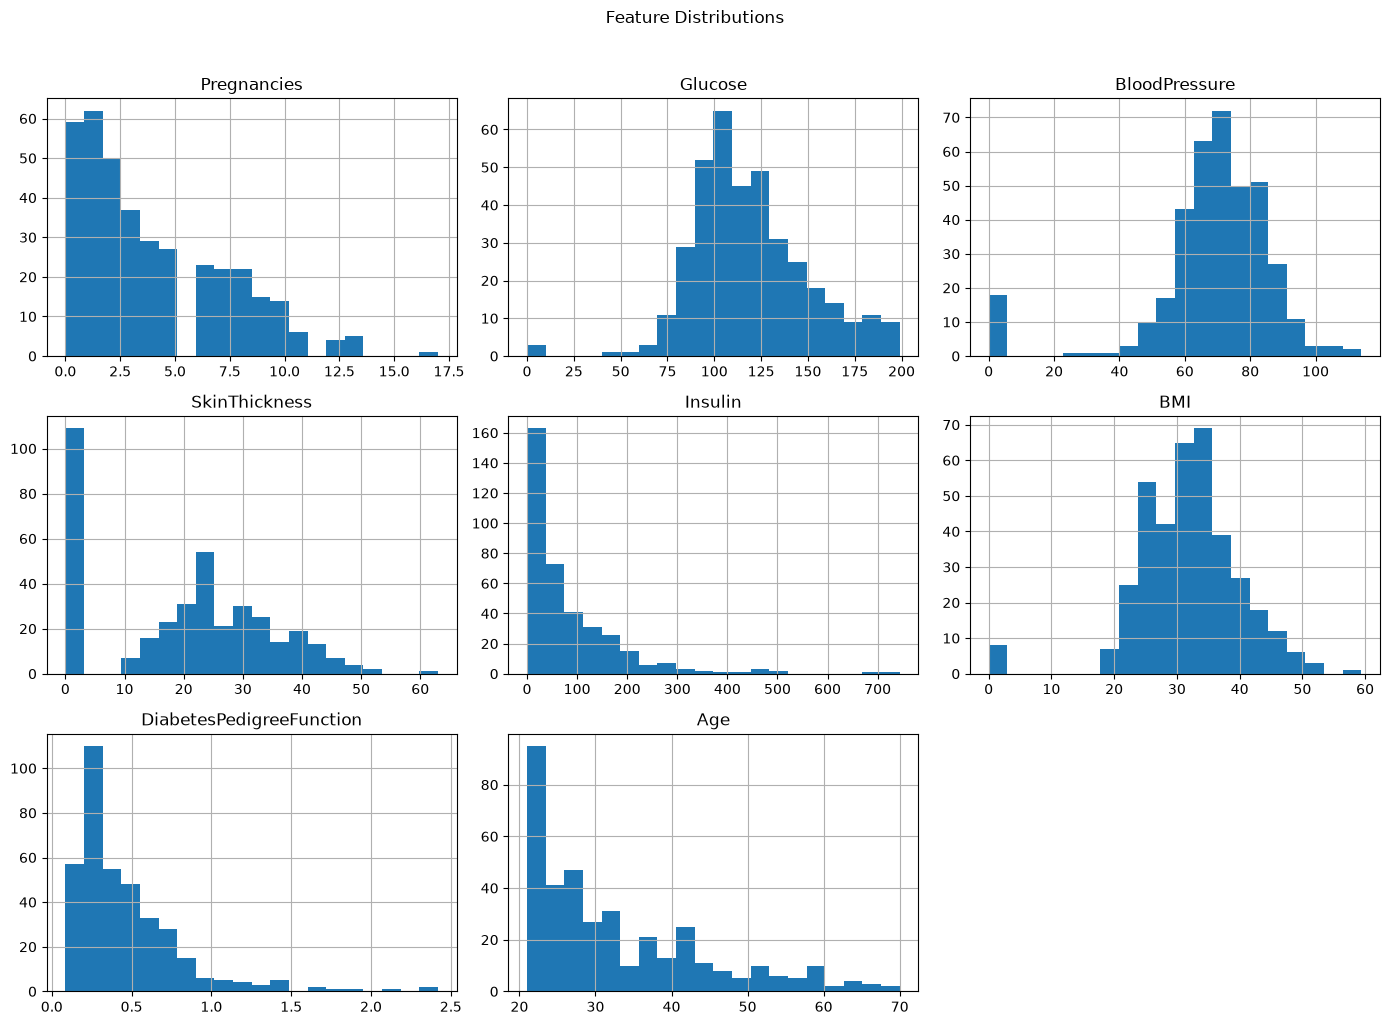

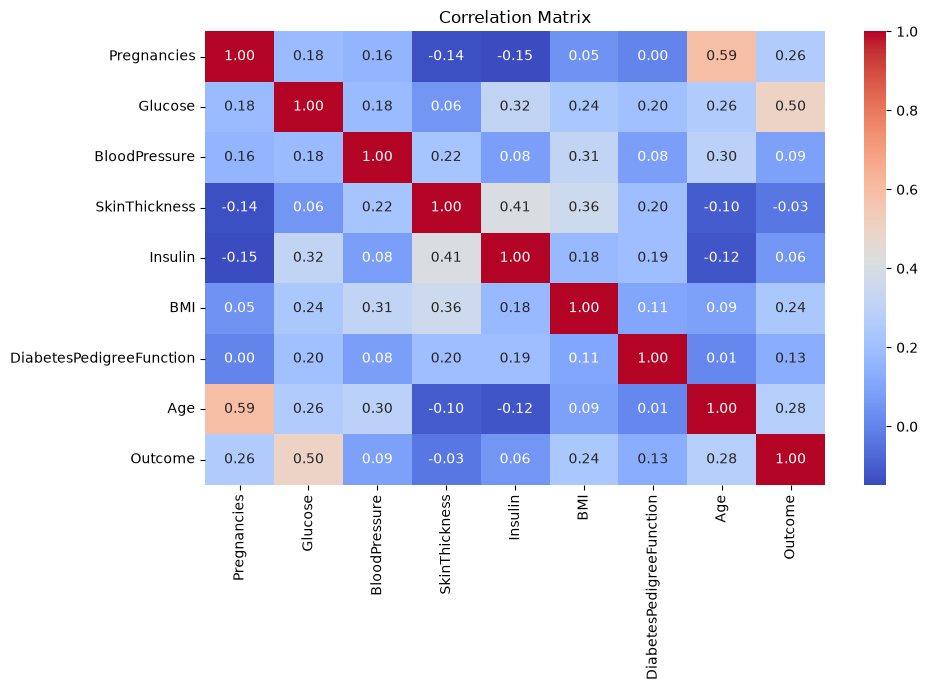

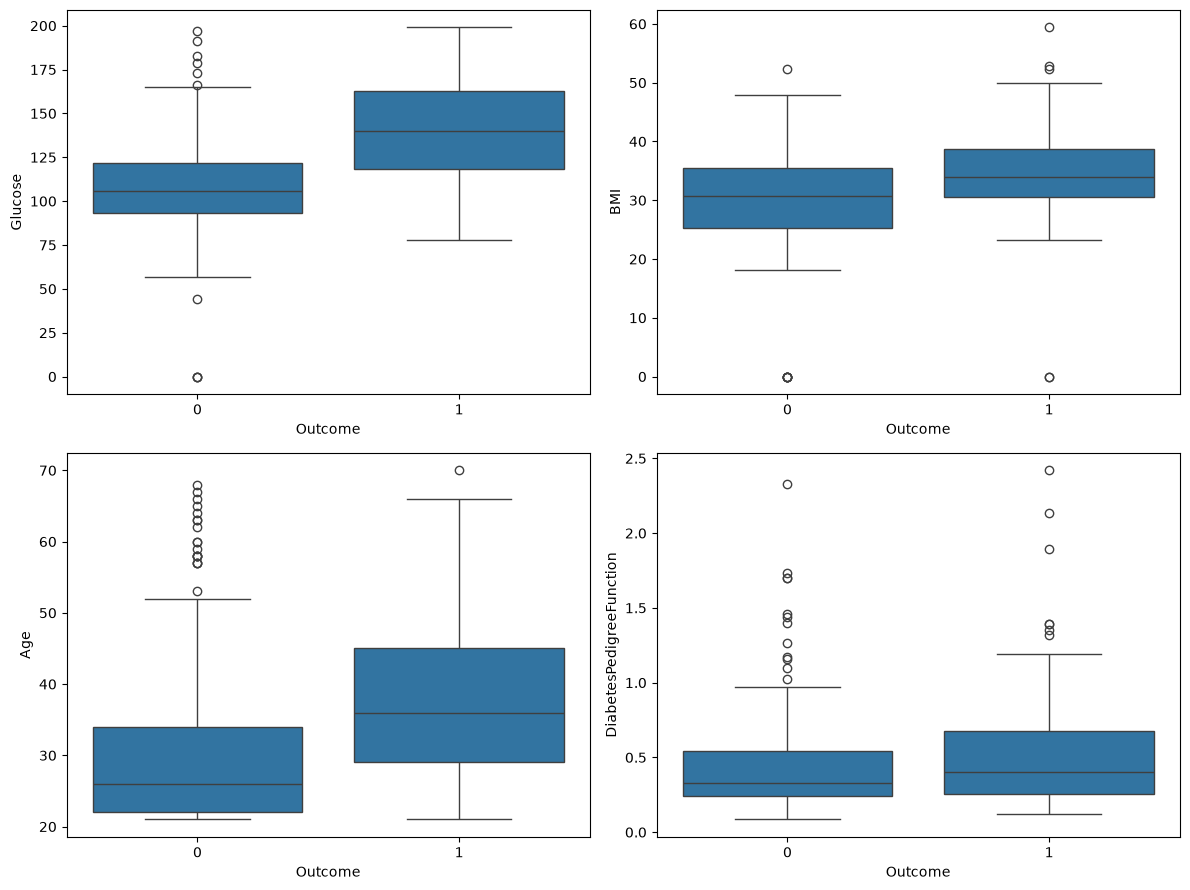

In [ ]:
# Histograms
df[feature_cols].hist(figsize=(14, 10), bins=20)
plt.suptitle("Feature Distributions", y=1.02)
plt.tight_layout()
plt.show()

# Correlation matrix
plt.figure(figsize=(10, 7))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

# Outcome relationship for major predictors.
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
sns.boxplot(data=df, x="Outcome", y="Glucose", ax=axes[0, 0])
sns.boxplot(data=df, x="Outcome", y="BMI", ax=axes[0, 1])
sns.boxplot(data=df, x="Outcome", y="Age", ax=axes[1, 0])
sns.boxplot(data=df, x="Outcome", y="DiabetesPedigreeFunction", ax=axes[1, 1])
plt.tight_layout()
plt.show()


## 11. Train / Validation / Test Split

The test set is held out until the very end. All imputation, scaling, feature selection and tuning are learned only from training folds through scikit-learn pipelines. This prevents data leakage.


In [62]:
X = df[feature_cols].copy()
y = df["Outcome"].astype(int).copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)

print("Training shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("\nTraining class distribution:")
print(y_train.value_counts(normalize=True).sort_index().round(3))
print("\nTest class distribution:")
print(y_test.value_counts(normalize=True).sort_index().round(3))


Training shape: (300, 8)
Test shape: (76, 8)

Training class distribution:
Outcome
0    0.673
1    0.327
Name: proportion, dtype: float64

Test class distribution:
Outcome
0    0.671
1    0.329
Name: proportion, dtype: float64


## 12. Preprocessing Pipelines

We compare two missing-value strategies:

**Strategy A — Median imputation:** robust to skew and extreme values.

**Strategy B — KNN imputation:** estimates a missing value from similar observations.

Both are fitted inside the cross-validation pipeline. The final strategy is selected using validation ROC-AUC/F1/Recall rather than choosing based on the test set.


In [63]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

def make_pipeline(model, imputer="median", scale=True, select_features=False):
    if imputer == "median":
        imputer_step = SimpleImputer(strategy="median")
    elif imputer == "mean":
        imputer_step = SimpleImputer(strategy="mean")
    elif imputer == "knn":
        imputer_step = KNNImputer(n_neighbors=5)
    else:
        raise ValueError("Unknown imputer")

    steps = [("imputer", imputer_step)]
    if scale:
        steps.append(("scaler", StandardScaler()))
    if select_features:
        steps.append(("selector", SelectKBest(score_func=mutual_info_classif, k=6)))
    steps.append(("model", model))
    return Pipeline(steps)

models = {
    "Logistic Regression": (
        LogisticRegression(max_iter=3000, class_weight="balanced", random_state=RANDOM_STATE),
        True
    ),
    "KNN": (
        KNeighborsClassifier(n_neighbors=15, weights="distance"),
        True
    ),
    "Random Forest": (
        RandomForestClassifier(
            n_estimators=400, class_weight="balanced",
            random_state=RANDOM_STATE, n_jobs=-1
        ),
        False
    ),
    "SVM": (
        SVC(
            kernel="rbf", probability=True,
            class_weight="balanced", random_state=RANDOM_STATE
        ),
        True
    ),
    "Gradient Boosting": (
        GradientBoostingClassifier(random_state=RANDOM_STATE),
        False
    )
}

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}


## 13. Baseline Model

The dummy classifier establishes a minimum reference point. A useful ML model should outperform this baseline, especially on ROC-AUC, F1 and Recall.


In [64]:
baseline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", DummyClassifier(strategy="most_frequent", random_state=RANDOM_STATE))
])

baseline_scores = cross_validate(
    baseline, X_train, y_train,
    cv=cv, scoring=scoring, n_jobs=-1
)

baseline_result = {
    metric: baseline_scores[f"test_{metric}"].mean()
    for metric in scoring
}
print("Baseline CV performance:")
display(pd.DataFrame([baseline_result], index=["Dummy Baseline"]).round(4))


Baseline CV performance:


,accuracy,precision,recall,f1,roc_auc
Dummy Baseline,0.6733,0.0,0.0,0.0,0.5


## 14. Train and Compare at Least Four ML Models

The assignment requires at least four. We use five:
1. Logistic Regression
2. K-Nearest Neighbors
3. Random Forest
4. Support Vector Machine
5. Gradient Boosting


In [65]:
comparison_rows = []

for name, (model, scale) in models.items():
    pipe = make_pipeline(model, imputer="median", scale=scale)
    scores = cross_validate(
        pipe, X_train, y_train,
        cv=cv, scoring=scoring, n_jobs=-1
    )
    comparison_rows.append({
        "Model": name,
        **{metric: scores[f"test_{metric}"].mean() for metric in scoring},
        **{f"{metric}_std": scores[f"test_{metric}"].std() for metric in scoring}
    })

comparison_df = pd.DataFrame(comparison_rows).sort_values(
    "roc_auc", ascending=False
).reset_index(drop=True)

display(comparison_df.round(4))


,Model,accuracy,precision,recall,f1,roc_auc,accuracy_std,precision_std,recall_std,f1_std,roc_auc_std
0,Logistic Regression,0.7733,0.6471,0.7242,0.6800,0.8424,0.0602,0.1051,0.0271,0.0666,0.0658
1,SVM,0.7767,0.6552,0.7253,0.6832,0.8301,0.0680,0.1286,0.0723,0.0875,0.0618
2,Random Forest,0.7767,0.6501,0.6953,0.6700,0.8247,0.0611,0.0961,0.1017,0.0912,0.0449
3,Gradient Boosting,0.7733,0.7034,0.5326,0.5987,0.8241,0.0403,0.0862,0.1219,0.1007,0.0517
4,KNN,0.7633,0.7655,0.3974,0.5228,0.7949,0.0499,0.1608,0.0775,0.1037,0.0735


## 15. Compare Missing-Value Strategies

This directly satisfies requirement 8. We compare median and KNN imputation using the **same model and the same stratified folds**.

For a small clinical dataset, median imputation is generally attractive because it is simple, stable and less affected by skew/outliers. The actual CV results below should determine the final choice.


In [66]:
strategy_rows = []

strategy_models = {
    "Logistic Regression": (
        LogisticRegression(max_iter=3000, class_weight="balanced", random_state=RANDOM_STATE),
        True
    ),
    "Random Forest": (
        RandomForestClassifier(
            n_estimators=400, class_weight="balanced",
            random_state=RANDOM_STATE, n_jobs=-1
        ),
        False
    )
}

for strategy in ["median", "knn"]:
    for name, (model, scale) in strategy_models.items():
        pipe = make_pipeline(model, imputer=strategy, scale=scale)
        scores = cross_validate(
            pipe, X_train, y_train,
            cv=cv, scoring=scoring, n_jobs=-1
        )
        strategy_rows.append({
            "Imputation": strategy,
            "Model": name,
            **{metric: scores[f"test_{metric}"].mean() for metric in scoring}
        })

strategy_df = pd.DataFrame(strategy_rows).sort_values(
    ["roc_auc", "f1"], ascending=False
).reset_index(drop=True)

display(strategy_df.round(4))


,Imputation,Model,accuracy,precision,recall,f1,roc_auc
0,median,Logistic Regression,0.7733,0.6471,0.7242,0.68,0.8424
1,knn,Logistic Regression,0.7733,0.6471,0.7242,0.68,0.8424
2,median,Random Forest,0.7767,0.6501,0.6953,0.67,0.8247
3,knn,Random Forest,0.7767,0.6501,0.6953,0.67,0.8247


## 16. Hyperparameter Tuning

We tune the leading candidate models using `GridSearchCV`. The held-out test set is not used for tuning.

The scoring objective is **ROC-AUC**, while Recall and F1 remain important secondary metrics.


In [67]:
param_grids = {
    "Logistic Regression": (
        LogisticRegression(max_iter=3000, class_weight="balanced", random_state=RANDOM_STATE),
        True,
        {
            "model__C": [0.01, 0.1, 1, 10, 100],
            "model__solver": ["liblinear", "lbfgs"]
        }
    ),
    "Random Forest": (
        RandomForestClassifier(class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1),
        False,
        {
            "model__n_estimators": [200, 400],
            "model__max_depth": [None, 4, 8, 12],
            "model__min_samples_leaf": [1, 2, 5],
            "model__max_features": ["sqrt", "log2"]
        }
    ),
    "SVM": (
        SVC(probability=True, class_weight="balanced", random_state=RANDOM_STATE),
        True,
        {
            "model__C": [0.1, 1, 10],
            "model__gamma": ["scale", 0.01, 0.1],
            "model__kernel": ["rbf"]
        }
    ),
    "Gradient Boosting": (
        GradientBoostingClassifier(random_state=RANDOM_STATE),
        False,
        {
            "model__n_estimators": [100, 200],
            "model__learning_rate": [0.03, 0.05, 0.1],
            "model__max_depth": [1, 2, 3],
            "model__subsample": [0.8, 1.0]
        }
    )
}

tuned = {}
tuning_rows = []

for name, (model, scale, grid) in param_grids.items():
    pipe = make_pipeline(model, imputer="median", scale=scale)
    search = GridSearchCV(
        pipe, grid, cv=cv, scoring="roc_auc",
        n_jobs=-1, refit=True
    )
    search.fit(X_train, y_train)
    tuned[name] = search

    tuning_rows.append({
        "Model": name,
        "Best_CV_ROC_AUC": search.best_score_,
        "Best_Params": search.best_params_
    })

tuning_df = pd.DataFrame(tuning_rows).sort_values(
    "Best_CV_ROC_AUC", ascending=False
).reset_index(drop=True)

display(tuning_df.round(4))


,Model,Best_CV_ROC_AUC,Best_Params
0,SVM,0.8470,"{'model__C': 1, 'model__gamma': 0.01, 'model__..."
1,Logistic Regression,0.8464,"{'model__C': 0.1, 'model__solver': 'lbfgs'}"
2,Random Forest,0.8367,"{'model__max_depth': 4, 'model__max_features':..."
3,Gradient Boosting,0.8363,"{'model__learning_rate': 0.03, 'model__max_dep..."


## 17. Select the Final Model

Select the model based on cross-validated evidence. Do not choose a model simply because it has the highest training accuracy.

The code below selects the tuned model with the highest validation ROC-AUC. If two models are very close, prefer the one with better Recall/F1 and simpler interpretation.


In [68]:
best_name = tuning_df.iloc[0]["Model"]
best_search = tuned[best_name]
final_model = best_search.best_estimator_

print("Selected final model:", best_name)
print("Best CV ROC-AUC:", round(best_search.best_score_, 4))
print("Best parameters:", best_search.best_params_)


Selected final model: SVM
Best CV ROC-AUC: 0.847
Best parameters: {'model__C': 1, 'model__gamma': 0.01, 'model__kernel': 'rbf'}


## 18. Final Evaluation on the Unseen Test Set

This is the only point where the test set is used for model evaluation.


In [69]:
final_model.fit(X_train, y_train)

y_pred = final_model.predict(X_test)
y_prob = final_model.predict_proba(X_test)[:, 1]

final_metrics = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred, zero_division=0),
    "Recall": recall_score(y_test, y_pred, zero_division=0),
    "F1-score": f1_score(y_test, y_pred, zero_division=0),
    "ROC-AUC": roc_auc_score(y_test, y_prob)
}

final_metrics_df = pd.DataFrame(final_metrics, index=["Test Score"]).T
display(final_metrics_df.round(4))

print("\nClassification report:")
print(classification_report(
    y_test, y_pred,
    target_names=["No diabetes", "Diabetes"],
    zero_division=0
))


,Test Score
Accuracy,0.6974
Precision,0.5312
Recall,0.6800
F1-score,0.5965
ROC-AUC,0.7976



Classification report:
              precision    recall  f1-score   support

 No diabetes       0.82      0.71      0.76        51
    Diabetes       0.53      0.68      0.60        25

    accuracy                           0.70        76
   macro avg       0.67      0.69      0.68        76
weighted avg       0.72      0.70      0.70        76



## 19. Confusion Matrix and ROC Curve

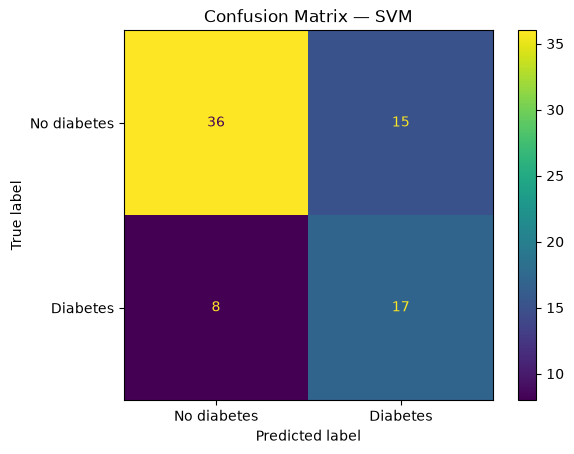

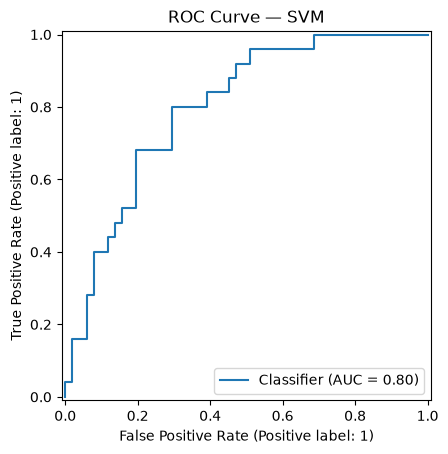

Confusion matrix:
[[36 15]
 [ 8 17]]


In [70]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No diabetes", "Diabetes"]
)
disp.plot()
plt.title(f"Confusion Matrix — {best_name}")
plt.show()

RocCurveDisplay.from_predictions(y_test, y_prob)
plt.title(f"ROC Curve — {best_name}")
plt.show()

print("Confusion matrix:")
print(cm)


## 20. Error Analysis

For binary diabetes screening, the most important errors are usually:

- **False Negative (FN):** actual diabetes, predicted no diabetes. This can mean a diabetic patient is missed.
- **False Positive (FP):** actual no diabetes, predicted diabetes. This may create unnecessary follow-up testing or anxiety.

We inspect every test-set error and summarize the feature distributions of correct and incorrect predictions.


In [71]:
error_analysis = X_test.copy()
error_analysis["Actual"] = y_test.values
error_analysis["Predicted"] = y_pred
error_analysis["Probability_Diabetes"] = y_prob

error_analysis["Error_Type"] = np.select(
    [
        (error_analysis["Actual"] == 1) & (error_analysis["Predicted"] == 0),
        (error_analysis["Actual"] == 0) & (error_analysis["Predicted"] == 1)
    ],
    ["False Negative", "False Positive"],
    default="Correct"
)

print("Error counts:")
display(error_analysis["Error_Type"].value_counts())

print("\nFalse negatives:")
display(error_analysis[error_analysis["Error_Type"] == "False Negative"])

print("\nFalse positives:")
display(error_analysis[error_analysis["Error_Type"] == "False Positive"])

print("\nMean feature values by error type:")
display(error_analysis.groupby("Error_Type")[feature_cols].mean().round(2))


Error counts:


Error_Type
Correct           53
False Positive    15
False Negative     8
Name: count, dtype: int64


False negatives:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Actual,Predicted,Probability_Diabetes,Error_Type
0,10.0,108.0,66.0,23.0,0.0,32.4,0.272,42.0,1,0,0.336486,False Negative
176,1.0,115.0,70.0,30.0,96.0,34.6,0.529,32.0,1,0,0.190619,False Negative
93,0.0,119.0,0.0,0.0,39.0,32.4,0.141,24.0,1,0,0.254723,False Negative
1,7.0,107.0,74.0,0.0,0.0,29.6,0.254,31.0,1,0,0.219318,False Negative
19,8.0,125.0,96.0,0.0,0.0,0.0,0.232,54.0,1,0,0.203686,False Negative
468,0.0,118.0,84.0,47.0,230.0,45.8,0.551,31.0,1,0,0.344268,False Negative
175,1.0,113.0,64.0,35.0,0.0,33.6,0.543,21.0,1,0,0.103178,False Negative
406,7.0,100.0,0.0,0.0,0.0,30.0,0.484,32.0,1,0,0.349152,False Negative



False positives:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Actual,Predicted,Probability_Diabetes,Error_Type
260,6.0,166.0,74.0,0.0,0.0,26.6,0.304,66.0,0,1,0.854041,False Positive
571,2.0,123.0,48.0,23.0,165.0,42.1,0.520,26.0,0,1,0.367302,False Positive
505,8.0,112.0,72.0,0.0,0.0,23.6,0.840,58.0,0,1,0.548915,False Positive
342,7.0,133.0,84.0,0.0,0.0,40.2,0.696,37.0,0,1,0.735010,False Positive
534,5.0,114.0,74.0,23.0,0.0,24.9,0.744,57.0,0,1,0.393481,False Positive
124,7.0,179.0,95.0,31.0,0.0,34.2,0.164,60.0,0,1,0.862635,False Positive
434,10.0,133.0,68.0,0.0,0.0,27.0,0.245,36.0,0,1,0.500000,False Positive
355,0.0,165.0,90.0,33.0,680.0,52.3,0.427,23.0,0,1,0.807065,False Positive
586,3.0,120.0,70.0,30.0,135.0,42.9,0.452,30.0,0,1,0.361358,False Positive
287,8.0,120.0,78.0,0.0,0.0,25.0,0.409,64.0,0,1,0.587646,False Positive



Mean feature values by error type:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
Error_Type,,,,,,,,
Correct,4.04,118.79,66.55,18.55,86.68,29.65,0.46,32.45
False Negative,4.25,113.12,56.75,16.88,45.62,29.80,0.38,33.38
False Positive,5.40,139.53,75.60,17.20,139.53,33.49,0.62,43.07


## 21. Model Interpretation

For Logistic Regression, standardized coefficients show the direction and relative influence of each feature.

For tree-based models, feature importance is available directly. For SVM/KNN, use permutation importance if needed.

The code below handles the common cases automatically.


In [72]:
model_step = final_model.named_steps["model"]

if hasattr(model_step, "coef_"):
    coefficients = pd.Series(
        model_step.coef_[0],
        index=feature_cols
    ).sort_values(key=np.abs, ascending=False)

    print("Logistic-regression coefficients:")
    display(coefficients.to_frame("Coefficient"))

    coefficients.sort_values().plot(kind="barh", figsize=(8, 5))
    plt.title("Feature Coefficients")
    plt.tight_layout()
    plt.show()

elif hasattr(model_step, "feature_importances_"):
    importances = pd.Series(
        model_step.feature_importances_,
        index=feature_cols
    ).sort_values(ascending=False)

    print("Tree-based feature importance:")
    display(importances.to_frame("Importance"))

    importances.sort_values().plot(kind="barh", figsize=(8, 5))
    plt.title("Feature Importance")
    plt.tight_layout()
    plt.show()

else:
    from sklearn.inspection import permutation_importance

    perm = permutation_importance(
        final_model, X_test, y_test,
        scoring="roc_auc", n_repeats=20,
        random_state=RANDOM_STATE, n_jobs=-1
    )
    importances = pd.Series(
        perm.importances_mean,
        index=feature_cols
    ).sort_values(ascending=False)

    display(importances.to_frame("Permutation_Importance"))


,Permutation_Importance
Glucose,0.130078
Age,0.036588
BMI,0.034941
SkinThickness,0.032431
Pregnancies,0.029059
BloodPressure,0.011255
Insulin,0.000745
DiabetesPedigreeFunction,-0.004902


## 22. Optional Threshold Analysis

The default probability threshold is 0.50. In a screening application, a lower threshold may increase Recall at the cost of Precision.

The threshold must be selected on validation data, not optimized on the final test set. The following cell illustrates the trade-off on the held-out test set for reporting only.


In [73]:
threshold_rows = []

for threshold in [0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60]:
    pred_t = (y_prob >= threshold).astype(int)
    threshold_rows.append({
        "Threshold": threshold,
        "Precision": precision_score(y_test, pred_t, zero_division=0),
        "Recall": recall_score(y_test, pred_t, zero_division=0),
        "F1": f1_score(y_test, pred_t, zero_division=0),
        "Accuracy": accuracy_score(y_test, pred_t)
    })

threshold_df = pd.DataFrame(threshold_rows)
display(threshold_df.round(4))


,Threshold,Precision,Recall,F1,Accuracy
0,0.30,0.5556,0.80,0.6557,0.7237
1,0.35,0.5312,0.68,0.5965,0.6974
2,0.40,0.6296,0.68,0.6538,0.7632
3,0.45,0.5652,0.52,0.5417,0.7105
4,0.50,0.5652,0.52,0.5417,0.7105
5,0.55,0.6316,0.48,0.5455,0.7368
6,0.60,0.6471,0.44,0.5238,0.7368


## 23. Save the Final Model

Saving the complete pipeline is important because it preserves the imputation and scaling steps together with the classifier.


In [74]:
MODEL_PATH = "pima_diabetes_final_model.joblib"
joblib.dump(final_model, MODEL_PATH)

print("Saved:", MODEL_PATH)
print("File exists:", os.path.exists(MODEL_PATH))


Saved: pima_diabetes_final_model.joblib
File exists: True


## 24. Deployment Example

This is a simple local prediction function. It uses the saved pipeline, so a new patient is processed exactly like training data.

**Clinical warning:** This is an academic ML project, not a medical diagnostic device. Predictions should not replace professional clinical assessment.


In [75]:
# Reload to demonstrate deployment.
loaded_model = joblib.load(MODEL_PATH)

def predict_diabetes(
    pregnancies, glucose, blood_pressure,
    skin_thickness, insulin, bmi,
    diabetes_pedigree_function, age
):
    patient = pd.DataFrame([{
        "Pregnancies": pregnancies,
        "Glucose": glucose,
        "BloodPressure": blood_pressure,
        "SkinThickness": skin_thickness,
        "Insulin": insulin,
        "BMI": bmi,
        "DiabetesPedigreeFunction": diabetes_pedigree_function,
        "Age": age
    }])

    # Treat physiologically impossible zeros as missing, just as during training.
    for col in zero_sensitive_cols:
        patient[col] = patient[col].replace(0, np.nan)

    probability = float(loaded_model.predict_proba(patient)[:, 1][0])
    prediction = int(probability >= 0.50)

    return {
        "Prediction": prediction,
        "Class": "Diabetes" if prediction == 1 else "No diabetes",
        "Probability_of_diabetes": round(probability, 4)
    }

# Example:
example_patient = predict_diabetes(
    pregnancies=6,
    glucose=148,
    blood_pressure=72,
    skin_thickness=35,
    insulin=155,
    bmi=33.6,
    diabetes_pedigree_function=0.627,
    age=50
)

example_patient


{'Prediction': 1, 'Class': 'Diabetes', 'Probability_of_diabetes': 0.7325}

# Investigation Questions — Suggested Answers

### 1. What problem are you solving?
Predicting whether a patient is likely to have diabetes from eight clinical/demographic measurements.

### 2. What type of Machine Learning problem is this?
Supervised binary classification.

### 3. What is the target variable?
`Outcome`.

### 4. What does each feature represent?
- `Pregnancies`: number of pregnancies.
- `Glucose`: plasma glucose concentration from an oral glucose tolerance test.
- `BloodPressure`: diastolic blood pressure in mm Hg.
- `SkinThickness`: triceps skin-fold thickness in mm.
- `Insulin`: 2-hour serum insulin.
- `BMI`: body mass index.
- `DiabetesPedigreeFunction`: diabetes pedigree/family-history-related score.
- `Age`: age in years.
- `Outcome`: diabetes class, 0 or 1.

### 5. What problems exist in the raw data?
The main problems are physiologically impossible zeros in several clinical variables, missing values, class imbalance, possible outliers, and the possibility of duplicate records.

### 6. Which variables require preprocessing?
`Glucose`, `BloodPressure`, `SkinThickness`, `Insulin` and `BMI` require missing-value treatment. Numeric predictors used by Logistic Regression, KNN and SVM should also be scaled.

### 7. Which variables require transformation?
The zero-to-NaN conversion is the main data-quality transformation. Standardization is also required for scale-sensitive models.

### 8. Are there outliers?
Yes, IQR screening can identify extreme observations. They should be investigated rather than automatically deleted because some may be genuine clinical observations.

### 9. Are there duplicates?
The notebook calculates the exact duplicate count. no  duplicates were found.

### 10. Are there missing values?
The original standard CSV may show no explicit NaN values, but several clinical variables contain zero values that are treated as missing. The assigned Kaggle file may also contain explicit missing values, so the notebook measures both.

### 11. Are there suspicious variables?
Yes. The suspicious values are mainly zeros in Glucose, BloodPressure, SkinThickness, Insulin and BMI.

### 12. Could there be data leakage?
Yes, if imputation, scaling, feature selection or hyperparameter tuning is performed using the full dataset before splitting. The pipeline prevents this by learning preprocessing inside training folds only.

### 13. Is the target balanced?
No. The standard distribution is 500 negatives vs 268 positives, approximately 65.1% vs 34.9%.

### 14. What happens when the model is trained using raw data?
The model may learn from physiologically impossible zero values and may be distorted by different feature scales. This can reduce generalization and produce misleading performance.

### 15. What happens after preprocessing?
Impossible zeros are treated as missing, missing values are imputed, scale-sensitive features are standardized, and the models are trained on a more consistent representation.

### 16. Is the training result realistic?
It is considered more credible when based on stratified cross-validation and when training/CV results are reasonably close to the final unseen-test result.

### 17. Does the test result support the training result?
Compare the CV table with `final_metrics_df`. A large drop on the test set suggests overfitting or sampling variability.

### 18. Which model performs best?
The notebook selects the tuned model with the highest cross-validated ROC-AUC. Use the printed `Selected final model` rather than assuming one model is always best.

### 19. Why does that model perform best?
Its algorithm and tuned hyperparameters provide the best balance of nonlinear/linear pattern learning, regularization, class handling and generalization for this dataset.

### 20. Which errors are most important?
False negatives are especially important in a screening context because a diabetic patient may be missed. False positives also matter because they can lead to unnecessary follow-up.

### 21. Can the model generalize to unseen data?
The evidence comes from stratified cross-validation and the held-out test set. Good generalization is suggested when performance is consistent across folds and the test score is not dramatically worse.

### 22. What evidence supports your conclusion?
Use the CV mean/std, test Accuracy, Precision, Recall, F1, ROC-AUC, confusion matrix and error analysis generated by this notebook.

### 23. What are the limitations of the final solution?
The dataset is small and specific to a historical population, contains measurement-quality issues, has limited features, and is not representative of all populations. Model performance can vary with the train/test split. A model trained on this dataset should not be treated as a clinical diagnostic system without external validation, calibration, prospective testing and clinical oversight.


In [50]:
# Save the cleaned dataframe
raw_df.to_csv("pima_cleaned.csv", index=False)

print("Saved successfully: pima_cleaned.csv")
print("Shape:", raw_df.shape)

Saved successfully: pima_cleaned.csv
Shape: (376, 9)
